# **1. Mixup, Cutmix, RandAugment 구현 (문서가 기니 목차와 셀 숨기기를 적극적으로 활용하세요!)**

## **1-1. Mixup, Cutmix, RandAugment을 구현하게 된  동기**
그동안 증강과 관련해 지식이 없어 데이터 증강 기법으로 Horizontal Flip, ColorJitter와 같은 기본적인 방법만 사용해왔습니다. 이제는 다양한 증강 기법을 적용해보며 어떤 증강 기법을 어느 상황에 적용해야 하는지 경험을 쌓을 필요가 있었기에, 증강과 관련된 논문을 읽으며 각 기법의 특성과 효과를 탐구하기로 했습니다.

여기서 다루는 증강 기법은 Mixup, Cutmix, RandAugment입니다. 해당 증강을 적용한 모델 학습은 Image Classification 레포지터리의 노트북에서 진행했습니다.

## **1-2. 구현에 참고한 논문**
**[1] Mixup: Beyond Empirical Risk Minimization**
([논문 링크](https://arxiv.org/abs/1710.09412))

논문을 읽기 전까지 저는 '데이터 증강'을 눈으로 봤을 때 현실적인 혹은 그럴듯해 보이는 데이터를 만드는 과정으로 이해하고 있었습니다. 하지만 이 논문을 통해 데이터 증강이 다소 비현실적인 데이터를 생성하는 것까지 포함하는 개념임을 확인할 수 있었습니다. 이 논문의 표현을 빌리면 모델이 훈련 데이터를 암기(Memorization)하는 것을 막기 위한 방법(Regularization) 중 하나가 데이터 증강이라고 합니다.

Mixup 기법은 모델의 데이터 암기를 방해하며 클래스 간 decision boundary를 부드럽게 만들어 주는 효과가 있다고 합니다. 또한 해당 기법을 사용했을 때 모델이 라벨 노이즈에 강건했다고 합니다. 이 논문에서 또 하나 기억에 남는 내용은 저자들이 Discussion 부분에서 얘기한 Feature level Mixup 이었습니다. Feature-level Mixup이 가능하다면 데이터의 형태(텍스트, 이미지)나 학습 방식(지도, 비지도)에 제약되지 않고 언제나 Mixup을 사용할 수 있을 테니 상당히 유용할 것 같다는 생각이 들었습니다. 이 논문이 나온 지 꽤 되었으니 누군가 이에 대해 이미 답을 내놓았겠죠..? 나중에 시간이 되면 찾아볼까 합니다.

Mixup 논문의 실험 결과를 몇 가지 정리하고 다음 논문으로 넘어가겠습니다.
- 3개 이상의 데이터를 Mixup 한다고 해서 성능이 더 향상되지는 않았다고 합니다.
- 같은 클래스의 데이터끼리 Mixup하는 것 또한 성능 향상에 도움이 되지 않았다고 합니다.
- 단독으로 쓰는 것보다 Dropout과 함께 쓸 때 효과적이었으며, Mixup을 사용할 때는 weight decay를 조금 줄이는 게 효과가 있었다고 합니다. (RandAugment 논문에서 나오는 이야기지만 과한 regularization은 모델 성능에 독이 된다고 합니다. Mixup 사용 시 weight decay를 작게 유지한 것이 성능에 긍정적인 영향을 준 것도 이와 비슷한 이유가 아닐까 추측해 봅니다.)

**[2] CutMix: Regularization Strategy to Train Strong Classifiers with Localizable Features**
([논문 링크](https://arxiv.org/abs/1905.04899))

지금까지 읽은 논문 중에서 우리나라 사람이 쓴 논문은 아마 이게 처음이 아닐까 싶습니다. 우리나라 사람이 작성해서 그런가 문장이 쉽게 읽혔습니다. 깔끔한 문장이었습니다.

Figure 1이 굉장히 임팩트있었습니다. 보자마자 이 논문의 아이디어가 무엇인지 바로 이해할 수 있었습니다. 해당 논문에서 Cutmix로 훈련시킨 모델이 Mixup, Cutout 데이터 모두에 적은 에러를 가지는 것을 보며 CutMix가 두 기법을 잘 혼합한 기법이라는 생각이 들었습니다. 라벨 노이즈에 강건하면서 클래스간 decision boundary를 부드럽게 만들어주는 Mixup의 장점과, 모델이 이미지의 특정 부분에만 집중하는 경향을 줄여주는 Cutout의 장점이 멋지게 합쳐진 기법이었습니다.

논문에 Cutmix를 비롯해 여러 증강 기법을 사용했을 때 각각 성능일 얼마나 개선되었는지를 기록한 표가 있었습니다. 해당 표를 보면서 '이런 증강도 있구나'하고 증강 기법들의 명칭을 눈에 익힐 수 있었습니다. 논문을 읽으면 항상 이런 목적 외 소득을 보게 되는 것 같습니다. 지식이 조금 늘은 것 같아 뿌듯합니다.

**[3] RandAugment: Practical automated data augmentation with a reduced search space**
([논문 링크](https://arxiv.org/abs/1909.13719))

AutoAugment는 다른 증강 기법보다 모델 성능을 더 높이 끌어올렸다고 합니다. 하지만 AutoAugment는 어떤 증강을 어느 강도로 적용하는 게 좋은지 탐색하는 과정이 필요하고 여기서 시간적, 계산적 비용이 증가하는 트레이드 오프가 있었습니다. 또한 AutoAugment로 찾은 증강 정책(policy)이 학습 모델에게도 최적의 정책인지가 모호했는데, 이러한 문제를 해결하면서 AutoAugment에 준하는 혹은 더 나은 성능 향상을 보여준 것이 이 RandAugment였습니다.

실험 하나 하나가 전달하는 내용이 굵직해서 읽으면서 정말 유익한 논문이라고 느꼈습니다. 개인적으로 모델과 데이터셋의 사이즈에 따라 최적의 증강 강도가 변함을 보여주는 Figure 3가 인상 깊었습니다. 이 논문을 접하기 전까지 저는 Regularization은 다다익선, 고고익선이라고 생각했는데 그게 아니었습니다. 지나친 Regularization은 독이 됨을 이 논문에서 배웠습니다.

특정 증강을 증강 후보 리스트에 포함/미포함시켰을 때 모델 성능이 어떻게 변하는지를 보여준 Figure 4도 멋진 그래프였습니다. rotate 증강을 포함시켰을 때 실험 성능 편차가 눈에 띄게 줄어드는 것을 볼 수 있었습니다. 확실히 좋은 논문엔 좋은 그래프가 많은 것 같습니다.

RandAugment 논문의 실험 결과를 몇 가지 정리하고 마치겠습니다.
- 증강 강도를 Constant, Random, Linearly Increasing 등 여러 방식으로 스케줄링해서 RandAugment를 시험해봤지만 성능은 대체로 동일했다.
- 증강별 증강 강도를 최적화하는 것이 성능 향상에 도움이 되긴 했지만, 그렇다고 모든 증강의 강도를 하나의 하이퍼파라미터로 통제하는 것이 성능을 그리 해치진 않았다.


**[4] AutoAugment: Learning Augmentation Policies from Data**
([논문 링크](https://arxiv.org/abs/1805.09501))

이 논문은 읽지 않았습니다. RandAugment의 magnitude=10에 해당하는 증강이 AutoAugment의 magnitude=10에 해당하는 증강과 동일하다고 나와있어서, AutoAugment에서 어떤 증강을 어느 정도로 적용했는지 파악하기 위해 해당 논문을 잠깐 봤습니다. 이 논문의 Table 6이 제가 찾던 것이었습니다.

## **1-3. 구현 후기**

각 기법을 구현한 섹션에 몇 가지 내용을 적었습니다. 학습은 다음 노트북에서 진행할 예정입니다.

## **1-4. 데이터 가져오기**

우선 Mixup, Cutmix, RandAugment에 사용할 데이터를 가져오겠습니다.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import math

transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    ])

dataset = datasets.Imagenette(root='./',
                              split = 'train',
                              size = 'full',
                              download = True,
                              transform = transform,
                              )

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

## **1-5. Mixup 구현**

아래는 Mixup 구현 및 결과입니다.

Mixup은 beta(alpha,alpha) 분포에서 샘플링한 람다 값을 바탕으로 두 이미지를 하나로 합성하는 증강 기법입니다.

라벨 노이즈에 강건하고 클래스 간 decision boundary가 부드러운 모델을 만들 때 사용하면 좋은 기법인 것 같습니다.

페이스북 리서치의 깃허브를 참고해 구현했습니다.

https://github.com/facebookresearch/mixup-cifar10

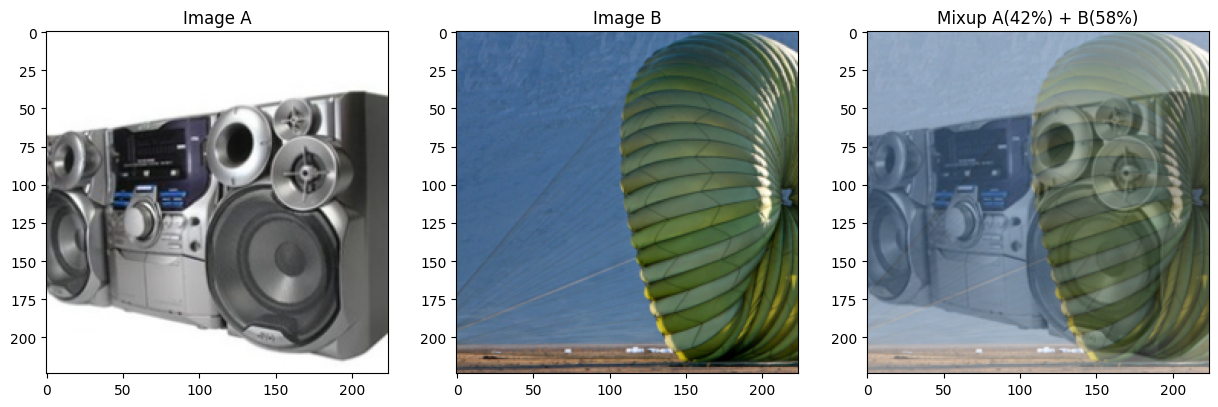

In [ ]:
class Mixup(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, image_A, target_A):
        rand_ind = torch.randperm(image_A.shape[0])
        image_B = image_A[rand_ind]
        target_B = target_A[rand_ind]

        lam = np.random.beta(self.alpha, self.alpha)
        mixup_image = lam * image_A + (1-lam) * image_B
        mixup_target = lam * target_A + (1-lam) * target_B

        return lam, mixup_image, mixup_target, image_B, target_B

alpha = 1.0
image_A, target_A = next(iter(dataloader))
lam, mixup_image, mixup_target, image_B, target_B = Mixup(alpha)(image_A, target_A)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_A[0].permute(1,2,0))
ax[0].set_title("Image A")

ax[1].imshow(image_B[0].permute(1,2,0))
ax[1].set_title("Image B")

ax[2].imshow(mixup_image[0].permute(1,2,0))
ax[2].set_title(f"Mixup A({lam*100:.0f}%) + B({(1-lam)*100:.0f}%)")
plt.show()

## **1-6. Cutmix 구현**

아래는 Cutmix 구현 및 결과입니다.

beta(1,1) 분포에서 샘플링한 람다 값을 바탕으로 한 이미지에 다른 이미지의 일부를 붙여 새로운 이미지를 만드는 증강 기법입니다.

Mixup과 Cutout의 장점을 모두 가져가고 싶을 때 사용하면 좋은 기법인 것 같습니다.

네이버 클로바AI의 깃허브를 참고해 코드를 작성했습니다.

https://github.com/clovaai/CutMix-PyTorch

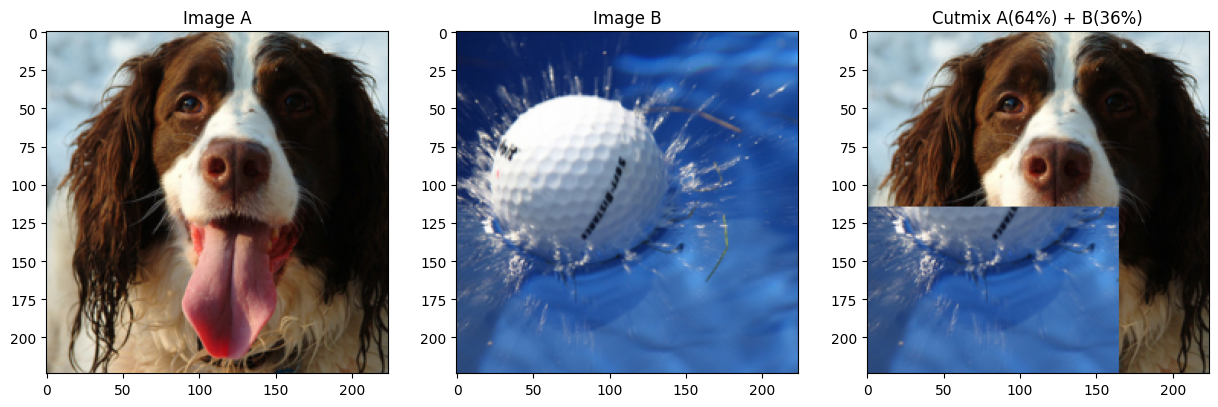

In [ ]:
class Cutmix(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, image_A, target_A):
        cutmix_image = image_A.clone()

        rand_ind = torch.randperm(image_A.shape[0])
        image_B = image_A[rand_ind]
        target_B = target_A[rand_ind]

        lam = np.random.beta(self.alpha, self.alpha)
        W, H = image_A.shape[-2:]

        r_x = np.random.uniform(W)
        r_y = np.random.uniform(H)
        r_w = int(W * np.sqrt(1.0-lam))
        r_h = int(H * np.sqrt(1.0-lam))

        x1 = int(np.clip(r_x - r_w // 2, 0, W))
        x2 = int(np.clip(r_x + r_w // 2, 0, W))
        y1 = int(np.clip(r_y - r_h // 2, 0, H))
        y2 = int(np.clip(r_y + r_h // 2, 0, H))

        cutmix_image[:, :, x1:x2, y1:y2] = image_B[:, :, x1:x2, y1:y2]

        lam = 1 - (x2-x1) * (y2-y1) / (W * H)

        cutmix_mask = torch.zeros(cutmix_image.shape)
        cutmix_mask[:, :, x1:x2, y1:y2] = 1

        return lam, cutmix_image, target_A, target_B, image_B, cutmix_mask

alpha = 1.0
image_A, target_A = next(iter(dataloader))
lam, cutmix_image, target_A, target_B, image_B, cutmix_mask = Cutmix(alpha)(image_A, target_A)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_A[0].permute(1,2,0))
ax[0].set_title("Image A")

ax[1].imshow(image_B[0].permute(1,2,0))
ax[1].set_title("Image B")

ax[2].imshow(cutmix_image[0].permute(1,2,0))
ax[2].set_title(f"Cutmix A({lam*100:.0f}%) + B({(1-lam)*100:.0f}%)")
plt.show()

## **1-7 Mixup & Cutmix with collate_fn**

collate_fn에 넣어 배치 단위 Mixup / Cutmix가 적용되도록 해봤습니다.

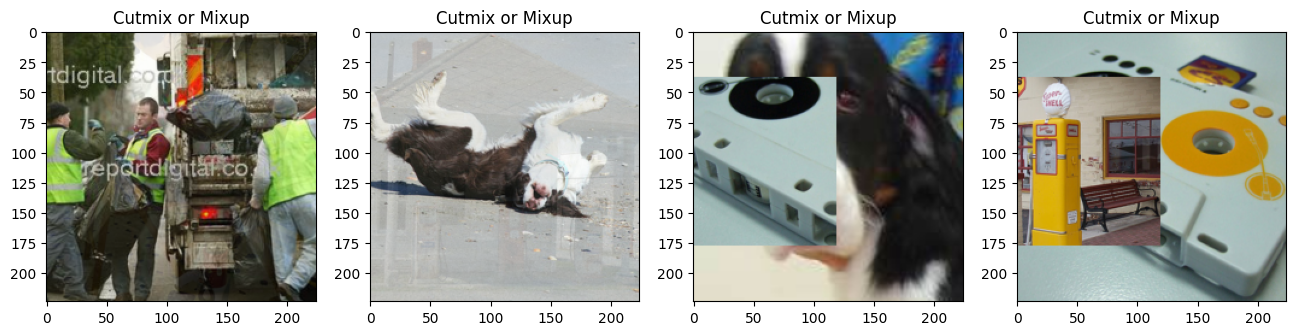

In [ ]:
from torch.utils.data import default_collate

cutmix_or_mixup = v2.RandomChoice([Cutmix(alpha=1.0), Mixup(alpha=1.0)])

def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))

dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=6, collate_fn=collate_fn)

alpha = 1.0
result1 = next(iter(dataloader))
result2 = next(iter(dataloader))

fig, ax = plt.subplots(1, 4, figsize=(16,4))
for i in range(2):
    ax[i].imshow(result1[1][i].permute(1,2,0))
    ax[i].set_title("Cutmix or Mixup")
for i in range(2,4):
    ax[i].imshow(result2[1][i].permute(1,2,0))
    ax[i].set_title("Cutmix or Mixup")
plt.show()

## **1-8. RandAugment 구현**
RandAugment 논문에서 제시한 RandAugment와  Pytorch에 구현된 RandAugment가 달라서 제가 논문을 제대로 이해한 게 맞나 여러 차례 확인했습니다. 처음엔 논문에서 말한 그대로 RandAugment를 구현하려 했습니다. 하지만 Pytorch 사람들이 조금 다르게 RandAugment를 구현한 데에는 그럴만한 이유가 있을 것이라고 생각해서 최종적으로는 저도 Pytorch의 방식을 따라 RandAugment를 구현하기로 했습니다.

논문에 나오는 RandAugment와 Pytorch의 RandAugment는 2가지 점에서 차이가 있었습니다.

1) 사용하는 증강 리스트: RandAugment 논문에선 invert, cutout, sample pairing을 증강 후보에 포함시켰습니다. 하지만 Pytorch에 구현된 RandAugment는 이들을 증강 후보에 포함하지 않았습니다.

2) 증강 강도(magnitude):
RandAugment 논문의 주석2에 따르면 RandAugment의 magnitude=10에 해당하는 증강은 AutoAugment의 magnitude=10과 동일한 수준의 증강이었다고 합니다. 그리고 RandAugment는 magnitude 최대치를 30으로 설정해 AutoAugment보다 3배 더 강한 증강을 시험했다고 합니다. (예를 들어, 만약 magnitude=10일 때 Rotation이 최대 30도까지 적용되었다면 magnitude=30일 때는 최대 90도까지 적용되도록 말이죠)
하지만 Pytorch에 구현된 RandAugment는 최대 magnitude=30에서 AutoAugment의 magnitude=10과 동일한 수준의 증강이 적용되도록 설계되어 있습니다.

Pytorch 사람들이 RandAugment를 시험한 결과, AutoAugment의 magnitude=10에 해당하는 수준의 증강으로도 충분한 regulization 효과를 볼 수 있었어서 RandAugment 코드를 이렇게 작성한 게 아닐까 추측해봅니다. 저도 이들을 믿고 따라가보겠습니다.

아래는 RandAugment 구현 및 결과입니다.

- custom v2.transform으로 만들어서 v2.Compose 안에 넣을 수 있게 했습니다.

- 학습 중 RandAugment의 magnitude를 변경할 수 있도록 RandAugment 클래스 내부에 set_magnitude 메서드를 넣어봤습니다. 나중에 이를 가지고 EfficientNetV2 논문에 나오는 Progressive Learning을 구현해보려 합니다.

In [ ]:
class RandAugment(nn.Module):
    def __init__(self, num_ops=2, magnitude=9, num_magnitude_bins=31):
        super().__init__()
        self.num_ops = num_ops
        self.magnitude = magnitude
        self.num_magnitude_bins = num_magnitude_bins
        relative_mag = magnitude / (num_magnitude_bins-1)

        augment_limit = {
            "Identity": 1.0,
            "ShearX": math.degrees(math.atan(0.3 * relative_mag)),
            "ShearY": math.degrees(math.atan(0.3 * relative_mag)),
            "TranslateX": 150.0 / 331.0 * relative_mag,
            "TranslateY": 150.0 / 331.0 * relative_mag,
            "Rotate": 30 * relative_mag,
            "Brightness": 0.9 * relative_mag,
            "Color": 0.9 * relative_mag,
            "Contrast": 0.9 * relative_mag,
            "Sharpness": 1.0 + 0.9 * relative_mag,
            "Posterize": int(round(8 - relative_mag * 4)),
            "Solarize": 255.0 * (1 - relative_mag),
            "AutoContrast": 1.0,
            "Equalize": 1.0,
        }

        self.augment_list = [
            v2.Identity(),
            v2.RandomAffine(degrees=0, shear=(-augment_limit["ShearX"], augment_limit["ShearX"], 0, 0)),    # ShearX
            v2.RandomAffine(degrees=0, shear=(0, 0, -augment_limit["ShearY"], augment_limit["ShearY"])),    # ShearY
            v2.RandomAffine(degrees=0, translate=(augment_limit["TranslateX"], 0)),                         # TranslateX
            v2.RandomAffine(degrees=0, translate=(0, augment_limit["TranslateY"])),                         # TranslateY

            v2.RandomRotation(degrees=augment_limit["Rotate"]),                                             # Rotate

            v2.ColorJitter(brightness=augment_limit["Brightness"]),                                         # Brightness
            v2.ColorJitter(saturation=augment_limit["Color"]),                                              # Color
            v2.ColorJitter(contrast=augment_limit["Contrast"]),                                             # Contrast

            v2.RandomAdjustSharpness(sharpness_factor=augment_limit["Sharpness"], p=1.0),                   # Sharpness
            v2.RandomPosterize(bits=augment_limit["Posterize"], p=1.0),                                     # Posterize
            v2.RandomSolarize(threshold=augment_limit["Solarize"], p=1.0),                                  # Solarize
            v2.RandomAutocontrast(p=augment_limit["AutoContrast"]),                                         # AutoContrast
            v2.RandomEqualize(p=augment_limit["Equalize"]),                                                 # Equalize
        ]

    def forward(self, image):
        augment_idx =  torch.randint(low=0,
                                     high=len(self.augment_list),
                                     size=(self.num_ops,))

        for idx in augment_idx:
            image = self.augment_list[idx](image)
        return image

    def set_magnitude(self, magnitude):
        relative_mag = magnitude / (self.num_magnitude_bins-1)

        augment_limit = {
            "Identity": 1.0,
            "ShearX": math.degrees(math.atan(0.3 * relative_mag)),
            "ShearY": math.degrees(math.atan(0.3 * relative_mag)),
            "TranslateX": 150.0 / 331.0 * relative_mag,
            "TranslateY": 150.0 / 331.0 * relative_mag,
            "Rotate": 30 * relative_mag,
            "Brightness": 0.9 * relative_mag,
            "Color": 0.9 * relative_mag,
            "Contrast": 0.9 * relative_mag,
            "Sharpness": 1.0 + 0.9 * relative_mag,
            "Posterize": int(round(8 - relative_mag * 4)),
            "Solarize": 255.0 * (1 - relative_mag),
            "AutoContrast": 1.0,
            "Equalize": 1.0,
        }

        self.augment_list = [
            v2.Identity(),
            v2.RandomAffine(degrees=0, shear=(-augment_limit["ShearX"], augment_limit["ShearX"], 0, 0)),    # ShearX
            v2.RandomAffine(degrees=0, shear=(0, 0, -augment_limit["ShearY"], augment_limit["ShearY"])),    # ShearY
            v2.RandomAffine(degrees=0, translate=(augment_limit["TranslateX"], 0)),                         # TranslateX
            v2.RandomAffine(degrees=0, translate=(0, augment_limit["TranslateY"])),                         # TranslateY

            v2.RandomRotation(degrees=augment_limit["Rotate"]),                                             # Rotate

            v2.ColorJitter(brightness=augment_limit["Brightness"]),                                         # Brightness
            v2.ColorJitter(saturation=augment_limit["Color"]),                                              # Color
            v2.ColorJitter(contrast=augment_limit["Contrast"]),                                             # Contrast

            v2.RandomAdjustSharpness(sharpness_factor=augment_limit["Sharpness"], p=1.0),                   # Sharpness
            v2.RandomPosterize(bits=augment_limit["Posterize"], p=1.0),                                     # Posterize
            v2.RandomSolarize(threshold=augment_limit["Solarize"], p=1.0),                                  # Solarize
            v2.RandomAutocontrast(p=augment_limit["AutoContrast"]),                                         # AutoContrast
            v2.RandomEqualize(p=augment_limit["Equalize"]),                                                 # Equalize
        ]

In [ ]:
def get_transform(transform_dict: dict, is_train=True):

    if is_train is False:
        val_transform = v2.Compose([
            v2.Resize(256),
            v2.CenterCrop(size=224),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
            ])
        return val_transform

    first_transform = v2.Compose([
        v2.Resize(256),
        v2.RandomCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        ])

    last_transform = v2.Compose([
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        ])

    middle_transform = []

    if transform_dict['RandAugment']['use']:
        rand_dict = transform_dict['RandAugment']
        middle_transform.append(RandAugment(num_ops = rand_dict['num_ops'],
                                            magnitude = rand_dict['magnitude'],
                                            num_magnitude_bins = rand_dict['num_magnitude_bins']))

    if len(middle_transform) > 0:
        middle_transform = v2.Compose(middle_transform)

        train_transform = v2.Compose([
            *(
            first_transform.transforms
            + middle_transform.transforms
            + last_transform.transforms
            )
        ])
    else:
        train_transform = v2.Compose([
            *(
            first_transform.transforms
            + last_transform.transforms
            )
        ])

    return train_transform

In [ ]:
# 나중에 YAML 파일로 지금까지 구현한 내용을 다 통합 정리할 예정이기에
# 여기서 미리 dict를 사용하는 연습을 해봅니다.

transform_dict = {
                "RandAugment": {
                                "use": True,
                                "num_ops": 2,
                                "magnitude": 30,
                                "num_magnitude_bins": 31,
                                },
                }

# train_transform. RandAugment()가 들어있는 게 보이시나요?
print(get_transform(transform_dict= transform_dict, is_train=True))

# val_transform. RandomCrop 대신 CenterCrop이 들어있습니다.
print(get_transform(transform_dict= transform_dict, is_train=False))

Compose(
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomCrop(size=(224, 224), pad_if_needed=False, fill=0, padding_mode=constant)
      ToImage()
      ToDtype(scale=True)
      RandAugment()
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


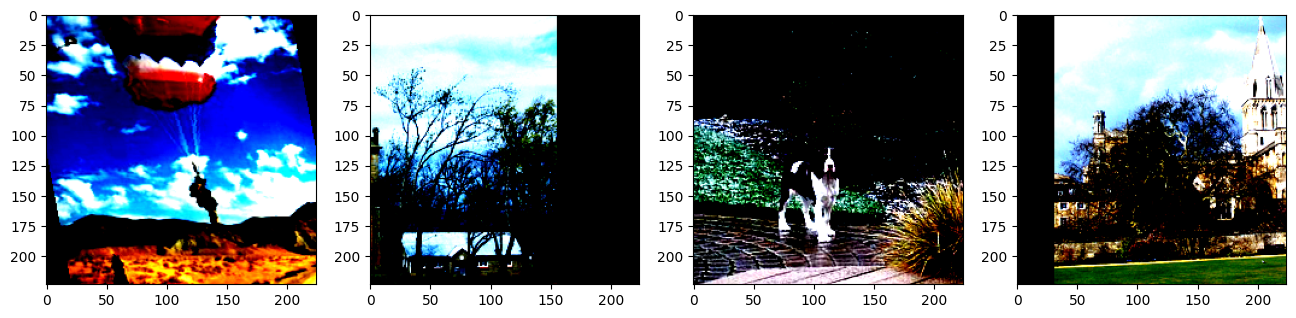

In [ ]:
dataset = datasets.Imagenette(root='./',
                              split = 'train',
                              size = 'full',
                              download = True,
                              transform = get_transform(transform_dict= transform_dict, is_train=True),
                              )

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
images, labels = next(iter(dataloader))
num_batches = images.shape[0]

fig, ax = plt.subplots(1, num_batches, figsize=(num_batches * 4, 4))
for i in range(num_batches):
    ax[i].imshow(images[i].permute(1,2,0))
plt.show()

# v2.Normalize를 거친 탓에 경고가 뜨네요 ㅎㅎ;

# **2. 학습 결과**

RA(N,M)에서 N은 적용한 증강 개수(num_ops), M은 증강 강도(magnitude) 입니다. (RA: RandAugment)  
증강별 성능 향상 정도를 공정하게 비교하려면 다회 실험 후 평균을 내야 하지만 시간이 없는 관계로 2회 실험 중 최고 성능을 기재했습니다.  
사용한 랜덤 시드: 13, 42  


| No. | 실험 모델 | 데이터 증강 | Validation Accuracy | 학습 시간 (L4 GPU) |
|-----|-----------|:-----------:|:-------------------:|--------------------|
| 1 | EfficientNetV2-B0 | X | 87.95% | 22분 (0.37분/epoch)|
| 2 | EfficientNetV2-B0 | Mixup(α=0.4) | +1.25% | 24분 (0.40분/epoch)|
| 3 | EfficientNetV2-B0 | Cutmix(α=1) | +1.20% | 24분 (0.40분/epoch)|
| 4 | EfficientNetV2-B0 | RA(N=2, M=3) | +0.64% | 24분 (0.40분/epoch)|
| 5 | EfficientNetV2-B0 | RA(N=2, M=5) | +0.74% | 24분 (0.40분/epoch)|
| 6 | EfficientNetV2-B0 | RA(N=2, M=7) | +1.17% | 24분 (0.40분/epoch)|
| 7 | EfficientNetV2-B0 | RA(N=2, M=9) | **+1.30%** | 24분 (0.40분/epoch)|
| 8 | EfficientNetV2-B0 | RA(N=2, M=11) | +1.15% | 24분 (0.40분/epoch)|
| 9 | EfficientNetV2-B0 | RA(N=2, M=13) | +0.87% | 24분 (0.40분/epoch)|

RandAugment의 증강 강도가 M=3 에서 M=13로 증가할 때 모델 성능이 가우시안 분포처럼 올라갔다가 내려가는 것이 보입니다.  
큰 고민 없이 M을 서서히 늘리거나 줄이는 것만으로 성능의 고점(?)을 볼 수 있다는 게 RandAugment의 이점인 것 같습니다.  